In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [308]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [309]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/csv/WISDM.csv',header=None)

In [310]:
df

,0,1,2,3,4,5,6
0,0,33,Jogging,4.910600e+13,-0.694638,12.680544,0.503953
1,1,33,Jogging,4.910610e+13,5.012288,11.264028,0.953424
2,2,33,Jogging,4.910610e+13,4.903325,10.882658,-0.081722
3,3,33,Jogging,4.910620e+13,-0.612916,18.496431,3.023717
4,4,33,Jogging,4.910630e+13,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...,...
1048570,1048571,7,Standing,2.091650e+14,-7.930000,5.430000,-0.990000
1048571,1048572,7,Standing,2.091660e+14,-7.970000,5.130000,-1.140000
1048572,1048573,7,Standing,2.091660e+14,-7.970000,5.220000,-1.380000
1048573,1048574,7,Standing,2.091660e+14,-7.930000,5.600000,-1.180000


In [311]:
df.columns = ['index', 'user', 'activity', 'timestamp', 'x', 'y', 'z']

In [312]:
df

,index,user,activity,timestamp,x,y,z
0,0,33,Jogging,4.910600e+13,-0.694638,12.680544,0.503953
1,1,33,Jogging,4.910610e+13,5.012288,11.264028,0.953424
2,2,33,Jogging,4.910610e+13,4.903325,10.882658,-0.081722
3,3,33,Jogging,4.910620e+13,-0.612916,18.496431,3.023717
4,4,33,Jogging,4.910630e+13,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...,...
1048570,1048571,7,Standing,2.091650e+14,-7.930000,5.430000,-0.990000
1048571,1048572,7,Standing,2.091660e+14,-7.970000,5.130000,-1.140000
1048572,1048573,7,Standing,2.091660e+14,-7.970000,5.220000,-1.380000
1048573,1048574,7,Standing,2.091660e+14,-7.930000,5.600000,-1.180000


In [313]:
df.shape

(1048575, 7)

In [314]:
df.isnull().values.any()

np.False_

In [315]:
df = df.drop(['index', 'timestamp','user'], axis=1)


In [316]:
df

,activity,x,y,z
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164
...,...,...,...,...
1048570,Standing,-7.930000,5.430000,-0.990000
1048571,Standing,-7.970000,5.130000,-1.140000
1048572,Standing,-7.970000,5.220000,-1.380000
1048573,Standing,-7.930000,5.600000,-1.180000


In [317]:
df['activity'].value_counts()

,count
activity,
Walking,406775
Jogging,325975
Upstairs,118589
Downstairs,97813
Sitting,54876
Standing,44547


In [318]:
LABELS = ["Jogging", "Sitting"]

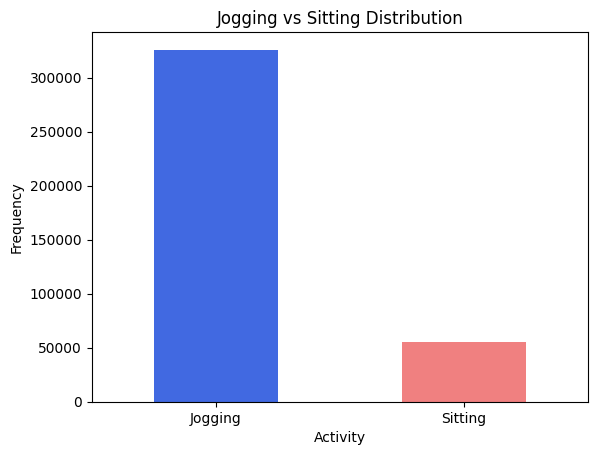

In [319]:
# 두 클래스만 추출
df = df[df['activity'].isin(['Jogging', 'Sitting'])]

# 각 클래스 빈도 계산
count_classes = df['activity'].value_counts().sort_index()

# 시각화
count_classes.plot(kind='bar', rot=0, color=['royalblue', 'lightcoral'])
plt.title("Jogging vs Sitting Distribution")
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.show()

In [320]:
# ====================================
# 2. 라벨 인코딩 및 정상/이상 클래스 설정
# ====================================
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["activity"])
id2name = {i: n for i, n in enumerate(le.classes_)}

# 여기서 조깅을 정상, 시팅을 이상으로 설정
NORMAL_NAME  = "Jogging"   # train 에만 들어갈 클래스
ANOMALY_NAME = "Sitting"   # 이상으로 잡고 싶은 클래스

if NORMAL_NAME not in le.classes_ or ANOMALY_NAME not in le.classes_:
    raise ValueError(f"'{NORMAL_NAME}' or '{ANOMALY_NAME}' no label. real={list(le.classes_)}")

normal_id  = le.transform([NORMAL_NAME])[0]
anomaly_id = le.transform([ANOMALY_NAME])[0]

print("normal_id :", normal_id, "->", NORMAL_NAME)
print("anomaly_id:", anomaly_id, "->", ANOMALY_NAME)

normal_id : 0 -> Jogging
anomaly_id: 1 -> Sitting


/tmp/ipython-input-3555182061.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label_id"] = le.fit_transform(df["activity"])


In [321]:


# ====================================
# 3. TRAIN = 조깅만, TEST = 조깅 + 시팅
# ====================================
df_train = df[df["label_id"] == normal_id].copy()
df_test  = df[df["label_id"].isin([normal_id, anomaly_id])].copy()

X_train = df_train[["x", "y", "z"]].to_numpy(dtype=np.float32)
X_test  = df_test[["x", "y", "z"]].to_numpy(dtype=np.float32)

# Sitting 을 1, Jogging 을 0 으로
y_test  = (df_test["label_id"].to_numpy() == anomaly_id).astype(int)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Test normal/anomaly ratio:", np.bincount(y_test))


Train shape: (325975, 3)
Test shape : (380851, 3)
Test normal/anomaly ratio: [325975  54876]


In [322]:
# ====================================
# 4. 표준화 (train에 fit, test에 transform)
# ====================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_train_s = X_train_s.astype("float32")
X_test_s  = X_test_s.astype("float32")


In [323]:
# ====================================
# 5. TensorFlow/Keras Autoencoder 정의
# ====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, roc_auc_score

in_dim = X_train_s.shape[1]   # 3

inputs = keras.Input(shape=(in_dim,), name="acc_input")
x = layers.Dense(32, activation="relu")(inputs)
z = layers.Dense(8, activation="relu", name="latent")(x)
x_hat = layers.Dense(32, activation="relu")(z)
outputs = layers.Dense(in_dim, name="recon")(x_hat)

autoencoder = keras.Model(inputs, outputs, name="ae_jog_sit")
autoencoder.summary()

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae"
)




Model: "ae_jog_sit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ acc_input (InputLayer)          │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recon (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 779 (3.04 KB)

 Trainable params: 779 (3.04 KB)

 Non-trainable params: 0 (0.00 B)

In [324]:
# ====================================
# 6. 조깅 데이터만 사용해서 학습
# ====================================
EPOCHS = 20
BATCH  = 1024

history = autoencoder.fit(
    X_train_s, X_train_s,
    epochs=EPOCHS,
    batch_size=BATCH,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.4765 - val_loss: 0.0171
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0132 - val_loss: 0.0088
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0074 - val_loss: 0.0060
Epoch 4/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0059 - val_loss: 0.0052
Epoch 5/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0054 - val_loss: 0.0052
Epoch 6/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047 - val_loss: 0.0043
Epoch 7/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 8/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - val_loss: 0.0029
Epoch 9/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 10/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 11/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0043 - val_loss: 0.0022
Epoch 12/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

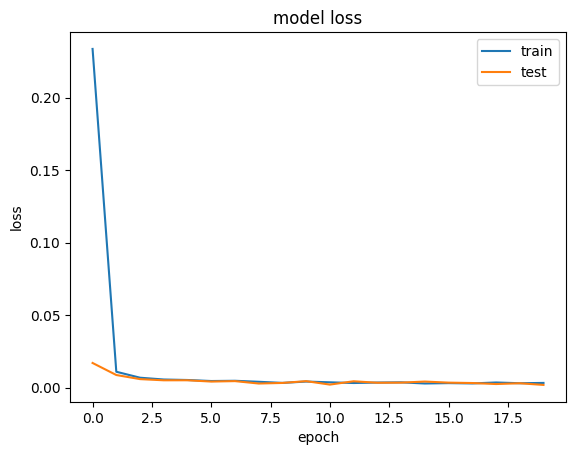

In [325]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right');

In [326]:
# ====================================
# 7. 재구성 오차 계산 (train, test)
# ====================================
recon_train = autoencoder.predict(X_train_s, batch_size=4096, verbose=0)
err_train = np.mean(np.abs(recon_train - X_train_s), axis=1)

recon_test = autoencoder.predict(X_test_s, batch_size=4096, verbose=0)
err_test = np.mean(np.abs(recon_test - X_test_s), axis=1)

print("Train error percentiles:", np.percentile(err_train, [50, 75, 90, 95, 99]))


Train error percentiles: [0.00166069 0.00247511 0.00351297 0.00437719 0.00626439]


In [327]:
# ====================================
# 8. threshold 설정 + 성능 평가
# ====================================
th = np.percentile(err_train, 95)   # 조깅 오차의 95퍼센타일
y_pred = (err_test > th).astype(int)

print("Threshold:", th)

print(classification_report(
    y_test,
    y_pred,
    target_names=[f"normal({NORMAL_NAME})", f"anomaly({ANOMALY_NAME})"]
))

auroc = roc_auc_score(y_test, err_test)
print("AUROC(조깅 vs 시팅 분리):", auroc)


Threshold: 0.004377188
                  precision    recall  f1-score   support

 normal(Jogging)       0.85      0.95      0.90    325975
anomaly(Sitting)       0.00      0.00      0.00     54876

        accuracy                           0.81    380851
       macro avg       0.42      0.47      0.45    380851
    weighted avg       0.73      0.81      0.77    380851

AUROC(조깅 vs 시팅 분리): 0.5042855484302083


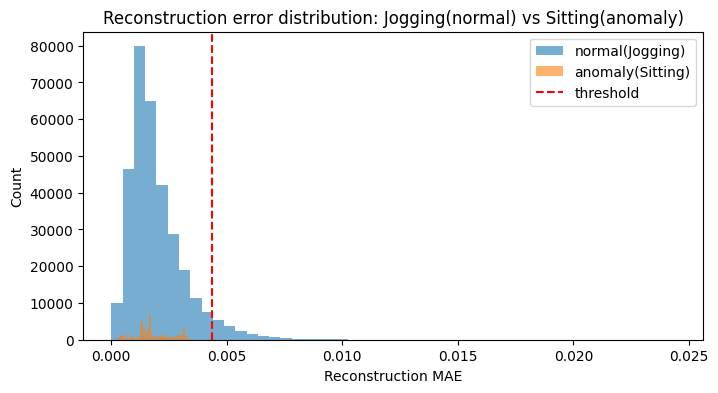

In [328]:
# ====================================
# 9. 오차 분포 시각화
# ====================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(err_test[y_test == 0], bins=50, alpha=0.6, label=f"normal({NORMAL_NAME})")
plt.hist(err_test[y_test == 1], bins=50, alpha=0.6, label=f"anomaly({ANOMALY_NAME})")
plt.axvline(th, color="red", linestyle="--", label="threshold")
plt.xlabel("Reconstruction MAE")
plt.ylabel("Count")
plt.legend()
plt.title(f"Reconstruction error distribution: {NORMAL_NAME}(normal) vs {ANOMALY_NAME}(anomaly)")
plt.show()